# Diabetic Retinopathy Severity Classification (APTOS 2019) — Advanced

This notebook **builds directly on the basic baseline**. There we trained two ResNets sequentially on one GPU and found clear weaknesses:

1. The second T4 GPU sat idle.
2. The two models were similar and never combined.
3. Class imbalance was ignored.
4. We had no idea *what* the models looked at.

Here we fix all of them, step by step:

- **Step A — Use both T4 GPUs.** Train **two models simultaneously**, one on `cuda:0` and one on `cuda:1`, via threads. With 4 models that's two parallel waves instead of four sequential runs.
- **Step B — Train 4 diverse models.** ResNet50, EfficientNet-B0, DenseNet121, ResNet18 — diversity for a stronger **ensemble**.
- **Step C — Handle imbalance.** Class-weighted loss + `WeightedRandomSampler` + stronger augmentation + cosine LR.
- **Step D — Ensemble.** Average softmax probabilities and compare against each single model.
- **Step E — Grad-CAM.** Overlay class-activation heatmaps to confirm the models attend to lesions.

We reuse the **same data setup** as the basic notebook, including the **balanced held-out test set**.

> **Hardware:** written for Kaggle's **2× NVIDIA T4** option. Set Accelerator = *GPU T4 x2* in the settings panel.

## 1. Imports & GPU check

In [1]:
import os, time, copy, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

torch.manual_seed(42); np.random.seed(42)

N_GPU = torch.cuda.device_count()
print("CUDA available:", torch.cuda.is_available(), "| GPUs:", N_GPU)
for i in range(N_GPU):
    print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")
if N_GPU < 2:
    print("\nWARNING: <2 GPUs. Parallel training falls back to one device. "
          "On Kaggle set Accelerator = 'GPU T4 x2'.")

CUDA available: True | GPUs: 2
  cuda:0 -> Tesla T4
  cuda:1 -> Tesla T4


## 2. Load the CSV & build paths (same source as basic)

In [2]:
DATA_ROOT = Path("/kaggle/input/aptos2019-blindness-detection")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("/kaggle/input/competitions/aptos2019-blindness-detection")
CSV_PATH   = DATA_ROOT / "train.csv"
IMAGES_DIR = DATA_ROOT / "train_images"
print("Root:", DATA_ROOT, "| exists:", DATA_ROOT.exists())

CLASSES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative_DR"]

df = pd.read_csv(CSV_PATH)
df["path"]  = df["id_code"].apply(lambda x: str(IMAGES_DIR / f"{x}.png"))
df["label"] = df["diagnosis"].astype(int)

if not df["path"].apply(os.path.exists).all():
    def resolve(idc):
        for ext in (".png", ".jpg", ".jpeg"):
            p = IMAGES_DIR / f"{idc}{ext}"
            if p.exists(): return str(p)
        return None
    df["path"] = df["id_code"].apply(resolve)
    df = df[df["path"].notna()].reset_index(drop=True)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index().to_dict())

Root: /kaggle/input/competitions/aptos2019-blindness-detection | exists: True
Total images: 3662
{0: 1805, 1: 370, 2: 999, 3: 193, 4: 295}


## 3. Balanced held-out test set (identical recipe to the basic notebook)

Same seed and same `TEST_PER_CLASS`, so the test set here is **exactly the same images** as in the basic notebook — results are directly comparable.

In [3]:
TEST_PER_CLASS = 50
min_class = df["label"].value_counts().min()
TEST_PER_CLASS = min(TEST_PER_CLASS, int(min_class * 0.5))
print("Test images per class:", TEST_PER_CLASS)

test_parts, remaining_parts = [], []
for c in range(5):
    sub = df[df["label"] == c]
    take = sub.sample(n=TEST_PER_CLASS, random_state=42)
    test_parts.append(take)
    remaining_parts.append(sub.drop(take.index))

test_df = pd.concat(test_parts).sample(frac=1, random_state=42).reset_index(drop=True)
pool_df = pd.concat(remaining_parts).reset_index(drop=True)

train_df, val_df = train_test_split(
    pool_df, test_size=0.15, stratify=pool_df["label"], random_state=42
)
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("Balanced test distribution:", test_df["label"].value_counts().sort_index().to_dict())

Test images per class: 50
Train: 2900 | Val: 512 | Test: 250
Balanced test distribution: {0: 50, 1: 50, 2: 50, 3: 50, 4: 50}


## 4. Class weights for imbalance

Improvement **#3**: inverse-frequency class weights (for the loss) and per-sample weights (for a `WeightedRandomSampler`).

In [4]:
counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
class_weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", dict(zip(CLASSES, np.round(class_weights.numpy(), 3))))

sample_weights = class_weights[train_df["label"].values].numpy()

Class weights: {'No_DR': np.float32(0.389), 'Mild': np.float32(2.132), 'Moderate': np.float32(0.719), 'Severe': np.float32(4.793), 'Proliferative_DR': np.float32(2.788)}


## 5. Stronger augmentation + datasets

Improvement **#5**: rotation, vertical flip, color jitter, small affine shift, on top of the horizontal flip the basic notebook used.

In [5]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class RetinaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["label"])

train_ds = RetinaDataset(train_df, train_tf)
val_ds   = RetinaDataset(val_df, eval_tf)
test_ds  = RetinaDataset(test_df, eval_tf)
print("Datasets ready:", len(train_ds), len(val_ds), len(test_ds))

Datasets ready: 2900 512 250


### Per-model loaders

Each model trains in its own thread on its own GPU, so each builds its own loaders. Training loaders use the `WeightedRandomSampler` so minority grades show up more often.

In [6]:
BATCH_SIZE = 32

def make_loaders():
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)
    return train_loader, val_loader

## 6. The 4 models

Improvement **#2**: four diverse architectures. Different designs make different mistakes, which is what makes the ensemble worthwhile.

In [7]:
def build_model(name, num_classes=5):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    else:
        raise ValueError(name)
    return m

MODEL_NAMES = ["resnet50", "efficientnet_b0", "densenet121", "resnet18"]
print("Will train:", MODEL_NAMES)

Will train: ['resnet50', 'efficientnet_b0', 'densenet121', 'resnet18']


## 7. Self-contained per-model training function

Each call trains one model on one device end-to-end: own loaders, weighted loss, Adam, cosine schedule. It only touches the device it's handed, so two calls can run concurrently on `cuda:0` and `cuda:1`.

In [8]:
EPOCHS = 10

def train_one_model(name, device_str, results, lock):
    device = torch.device(device_str)
    model = build_model(name).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    train_loader, val_loader = make_loaders()

    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    for epoch in range(EPOCHS):
        model.train(); running = 0.0; n = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()
            running += loss.item() * imgs.size(0); n += imgs.size(0)
        scheduler.step()
        train_loss = running / n

        model.eval(); vloss = 0.0; correct = 0; vn = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vloss += criterion(out, labels).item() * imgs.size(0)
                correct += (out.argmax(1) == labels).sum().item(); vn += imgs.size(0)
        val_loss = vloss / vn; val_acc = correct / vn
        hist["train_loss"].append(train_loss); hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc = val_acc; best_state = copy.deepcopy(model.state_dict())
        print(f"[{name:>16} @ {device_str}] epoch {epoch+1:2d}/{EPOCHS}  "
              f"train_loss {train_loss:.3f}  val_loss {val_loss:.3f}  val_acc {val_acc:.3f}")

    model.load_state_dict(best_state); model.to("cpu")
    with lock:
        results[name] = {"model": model, "history": hist, "best_acc": best_acc}
    torch.cuda.empty_cache()

## 8. Train two models at a time, one per GPU

Improvement **#1**. Two waves:
- **Wave 1:** `resnet50` on `cuda:0`, `efficientnet_b0` on `cuda:1` — in parallel.
- **Wave 2:** `densenet121` on `cuda:0`, `resnet18` on `cuda:1` — in parallel.

Threads overlap because CUDA kernels release the GIL while the GPU is busy. With one GPU, everything maps to `cuda:0` and serializes — still correct.

In [9]:
def device_for(slot):
    if N_GPU >= 2: return f"cuda:{slot}"
    return "cuda:0" if torch.cuda.is_available() else "cpu"

waves = [MODEL_NAMES[i:i+2] for i in range(0, len(MODEL_NAMES), 2)]
print("Training waves:", waves)

results = {}; lock = threading.Lock(); t_start = time.time()
for w, wave in enumerate(waves):
    print(f"\n===== WAVE {w+1}: {wave} =====")
    threads = []
    for slot, name in enumerate(wave):
        t = threading.Thread(target=train_one_model, args=(name, device_for(slot), results, lock))
        t.start(); threads.append(t)
    for t in threads: t.join()

print(f"\nAll models trained in {time.time()-t_start:.0f}s")
for name in MODEL_NAMES:
    print(f"  {name:>16}  best val_acc = {results[name]['best_acc']:.3f}")

Training waves: [['resnet50', 'efficientnet_b0'], ['densenet121', 'resnet18']]

===== WAVE 1: ['resnet50', 'efficientnet_b0'] =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/20.5M [00:00<?, ?B/s]
 30%|██▉       | 6.12M/20.5M [00:00<00:00, 63.8MB/s]
100%|██████████| 20.5M/20.5M [00:00<00:00, 108MB/s] 

 24%|██▍       | 23.5M/97.8M [00:00<00:00, 133MB/s] 
 37%|███▋      | 36.2M/97.8M [00:00<00:00, 132MB/s]
 54%|█████▎    | 52.4M/97.8M [00:00<00:00, 146MB/s]
 70%|███████   | 68.6M/97.8M [00:00<00:00, 154MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


[        resnet50 @ cuda:0] epoch  1/10  train_loss 1.138  val_loss 1.371  val_acc 0.225
[ efficientnet_b0 @ cuda:1] epoch  1/10  train_loss 1.162  val_loss 1.273  val_acc 0.516
[        resnet50 @ cuda:0] epoch  2/10  train_loss 0.730  val_loss 1.191  val_acc 0.488
[ efficientnet_b0 @ cuda:1] epoch  2/10  train_loss 0.767  val_loss 1.157  val_acc 0.561
[        resnet50 @ cuda:0] epoch  3/10  train_loss 0.528  val_loss 1.135  val_acc 0.592
[ efficientnet_b0 @ cuda:1] epoch  3/10  train_loss 0.586  val_loss 1.106  val_acc 0.633
[        resnet50 @ cuda:0] epoch  4/10  train_loss 0.396  val_loss 1.100  val_acc 0.650
[ efficientnet_b0 @ cuda:1] epoch  4/10  train_loss 0.473  val_loss 1.150  val_acc 0.643
[        resnet50 @ cuda:0] epoch  5/10  train_loss 0.339  val_loss 1.117  val_acc 0.709
[ efficientnet_b0 @ cuda:1] epoch  5/10  train_loss 0.421  val_loss 1.116  val_acc 0.660
[        resnet50 @ cuda:0] epoch  6/10  train_loss 0.272  val_loss 1.185  val_acc 0.736
[ efficientnet_b0 @ c

 21%|██        | 9.25M/44.7M [00:00<00:00, 96.9MB/s]

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



 50%|████▉     | 22.1M/44.7M [00:00<00:00, 119MB/s] 
 87%|████████▋ | 38.8M/44.7M [00:00<00:00, 144MB/s]]
100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]]

100%|██████████| 30.8M/30.8M [00:00<00:00, 84.8MB/s]


[        resnet18 @ cuda:1] epoch  1/10  train_loss 0.952  val_loss 1.172  val_acc 0.602
[     densenet121 @ cuda:0] epoch  1/10  train_loss 0.910  val_loss 1.065  val_acc 0.623
[        resnet18 @ cuda:1] epoch  2/10  train_loss 0.634  val_loss 1.059  val_acc 0.625
[     densenet121 @ cuda:0] epoch  2/10  train_loss 0.571  val_loss 1.065  val_acc 0.643
[        resnet18 @ cuda:1] epoch  3/10  train_loss 0.481  val_loss 1.046  val_acc 0.660
[     densenet121 @ cuda:0] epoch  3/10  train_loss 0.453  val_loss 1.034  val_acc 0.668
[        resnet18 @ cuda:1] epoch  4/10  train_loss 0.435  val_loss 1.131  val_acc 0.678
[     densenet121 @ cuda:0] epoch  4/10  train_loss 0.339  val_loss 1.062  val_acc 0.723
[        resnet18 @ cuda:1] epoch  5/10  train_loss 0.330  val_loss 1.147  val_acc 0.693
[     densenet121 @ cuda:0] epoch  5/10  train_loss 0.314  val_loss 1.008  val_acc 0.764
[        resnet18 @ cuda:1] epoch  6/10  train_loss 0.300  val_loss 1.144  val_acc 0.729
[     densenet121 @ c

## 9. Training curves across the 4 models

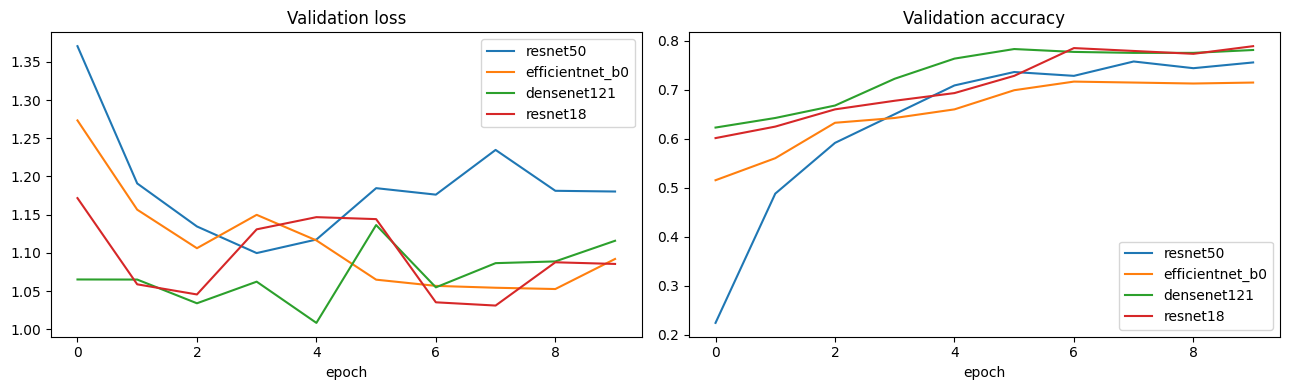

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name in MODEL_NAMES:
    h = results[name]["history"]
    ax[0].plot(h["val_loss"], label=name)
    ax[1].plot(h["val_acc"], label=name)
ax[0].set_title("Validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Per-model predictions on the balanced TEST set

We store softmax probabilities so we can score each model and build the ensemble. The test loader is fixed-order so every model's predictions line up row-by-row.

In [11]:
infer_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
y_true = np.array([test_ds[i][1] for i in range(len(test_ds))])

prob_store = {}
for name in MODEL_NAMES:
    model = results[name]["model"].to(infer_device).eval()
    probs = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(infer_device)
            probs.append(F.softmax(model(imgs), dim=1).cpu().numpy())
    prob_store[name] = np.concatenate(probs, axis=0)
    model.to("cpu"); torch.cuda.empty_cache()
    print(f"{name:>16}  test_acc = {accuracy_score(y_true, prob_store[name].argmax(1)):.4f}")

        resnet50  test_acc = 0.6520
 efficientnet_b0  test_acc = 0.6760
     densenet121  test_acc = 0.6840
        resnet18  test_acc = 0.7040


## 11. The ensemble

Improvement **#4**: average the four probability matrices, then argmax.

In [12]:
ensemble_prob = np.mean([prob_store[n] for n in MODEL_NAMES], axis=0)
ensemble_pred = ensemble_prob.argmax(1)

print("=== Individual vs Ensemble (balanced test accuracy) ===")
for name in MODEL_NAMES:
    print(f"  {name:>16}: {accuracy_score(y_true, prob_store[name].argmax(1)):.4f}")
print(f"  {'ENSEMBLE':>16}: {accuracy_score(y_true, ensemble_pred):.4f}")

print("\nEnsemble classification report:")
print(classification_report(y_true, ensemble_pred, target_names=CLASSES, zero_division=0))

=== Individual vs Ensemble (balanced test accuracy) ===
          resnet50: 0.6520
   efficientnet_b0: 0.6760
       densenet121: 0.6840
          resnet18: 0.7040
          ENSEMBLE: 0.7080

Ensemble classification report:
                  precision    recall  f1-score   support

           No_DR       0.98      1.00      0.99        50
            Mild       0.65      0.94      0.77        50
        Moderate       0.64      0.56      0.60        50
          Severe       0.79      0.46      0.58        50
Proliferative_DR       0.54      0.58      0.56        50

        accuracy                           0.71       250
       macro avg       0.72      0.71      0.70       250
    weighted avg       0.72      0.71      0.70       250



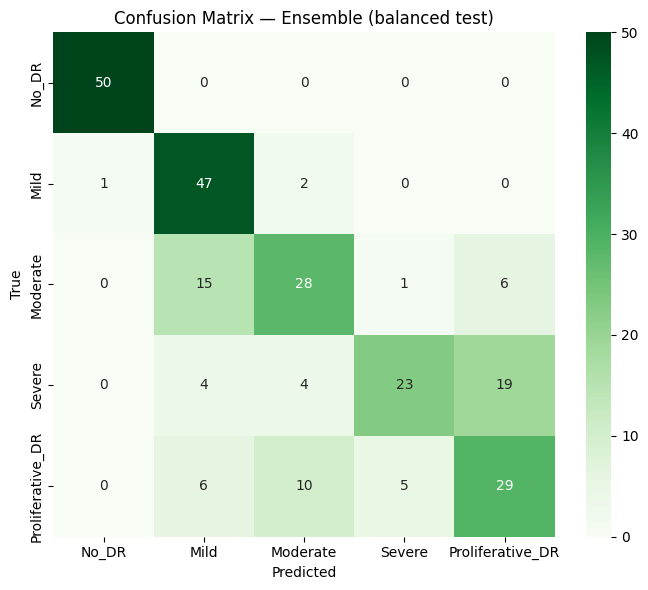

In [13]:
cm = confusion_matrix(y_true, ensemble_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — Ensemble (balanced test)")
plt.tight_layout(); plt.show()

## 12. Save everything

In [14]:
for name in MODEL_NAMES:
    torch.save(results[name]["model"].state_dict(), f"{name}_advanced.pth")
np.save("ensemble_test_probs.npy", ensemble_prob)
print("Saved 4 model weights + ensemble probabilities.")

Saved 4 model weights + ensemble probabilities.


## 13. Grad-CAM — what is the model looking at?

Improvement **#6**, and the most important clinically. High accuracy is meaningless if the model keys on a black border or camera artifact instead of real lesions (microaneurysms, hemorrhages, exudates).

**Grad-CAM**: take the last conv layer, grab its activations on a forward pass, backprop the predicted class score to get gradients w.r.t. those activations, GAP the gradients into per-channel weights, weight + ReLU + upsample. We implement it with hooks — no external library.

In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.activations = None; self.gradients = None
        self.fwd = target_layer.register_forward_hook(self._save_act)
        self.bwd = target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o):  self.activations = o.detach()
    def _save_grad(self, m, gi, go): self.gradients = go[0].detach()
    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if class_idx is None: class_idx = logits.argmax(1).item()
        self.model.zero_grad(); logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx
    def remove(self): self.fwd.remove(); self.bwd.remove()

### Target layer per architecture

In [16]:
def last_conv_layer(model, name):
    if name in ("resnet50", "resnet18"): return model.layer4[-1]
    if name == "densenet121":            return model.features[-1]
    if name == "efficientnet_b0":        return model.features[-1]
    raise ValueError(name)

### Overlay helper — denormalize, then lay the heatmap on top

In [17]:
inv_mean = torch.tensor(mean).view(3,1,1)
inv_std  = torch.tensor(std).view(3,1,1)
def denormalize(t):
    img = t.cpu() * inv_std + inv_mean
    return img.clamp(0,1).permute(1,2,0).numpy()

def show_gradcam_grid(model_name, n_examples=5):
    model = results[model_name]["model"].to(infer_device).eval()
    cam_engine = GradCAM(model, last_conv_layer(model, model_name))
    idxs = []
    for c in range(5):
        cand = np.where(y_true == c)[0]
        if len(cand): idxs.append(cand[0])
    idxs = idxs[:n_examples]
    fig, axes = plt.subplots(2, len(idxs), figsize=(4*len(idxs), 7))
    for col, idx in enumerate(idxs):
        img_t, true_lbl = test_ds[idx]
        x = img_t.unsqueeze(0).to(infer_device)
        cam, pred = cam_engine(x)
        base = denormalize(img_t)
        axes[0, col].imshow(base); axes[0, col].set_title(f"true: {CLASSES[true_lbl]}"); axes[0, col].axis("off")
        axes[1, col].imshow(base); axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, col].set_title(f"pred: {CLASSES[pred]}"); axes[1, col].axis("off")
    plt.suptitle(f"Grad-CAM — {model_name}", fontsize=14)
    plt.tight_layout(); plt.show()
    cam_engine.remove(); model.to("cpu"); torch.cuda.empty_cache()

Best single model: resnet18


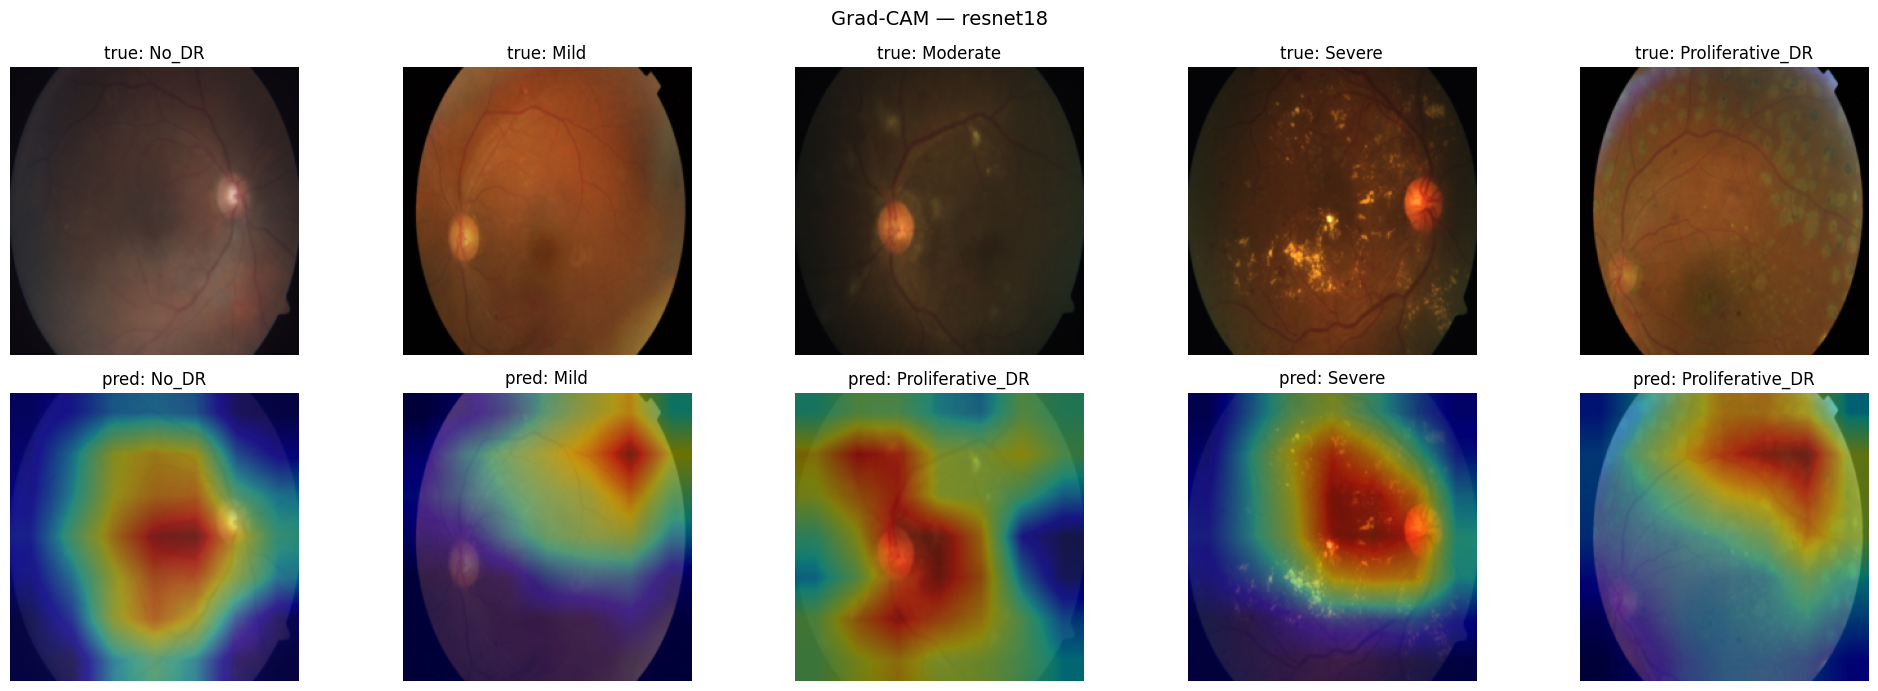

In [18]:
best_model_name = max(MODEL_NAMES, key=lambda n: results[n]["best_acc"])
print("Best single model:", best_model_name)
show_gradcam_grid(best_model_name, n_examples=5)

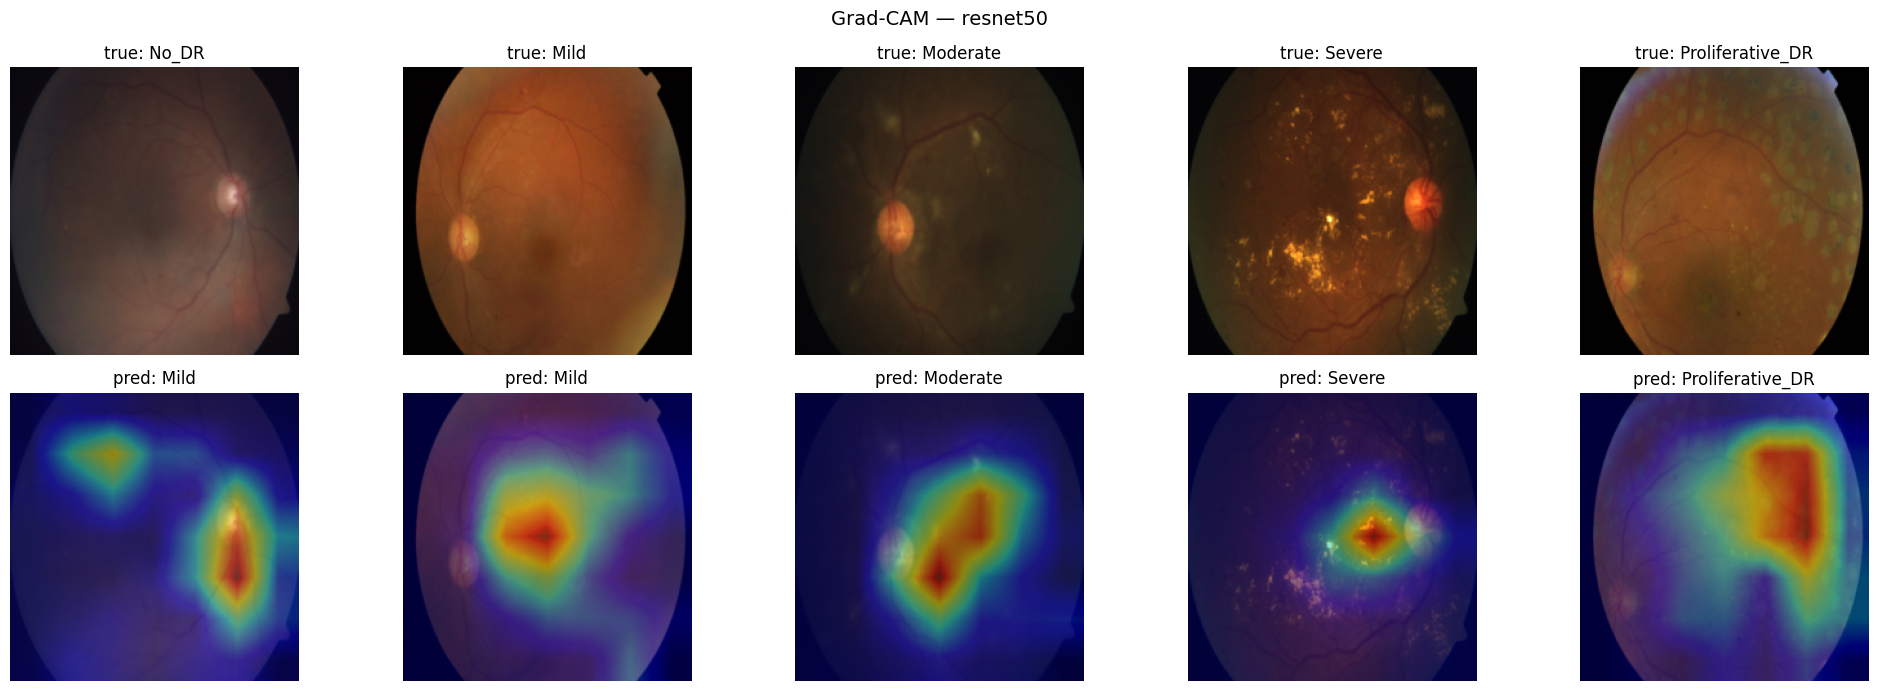

RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

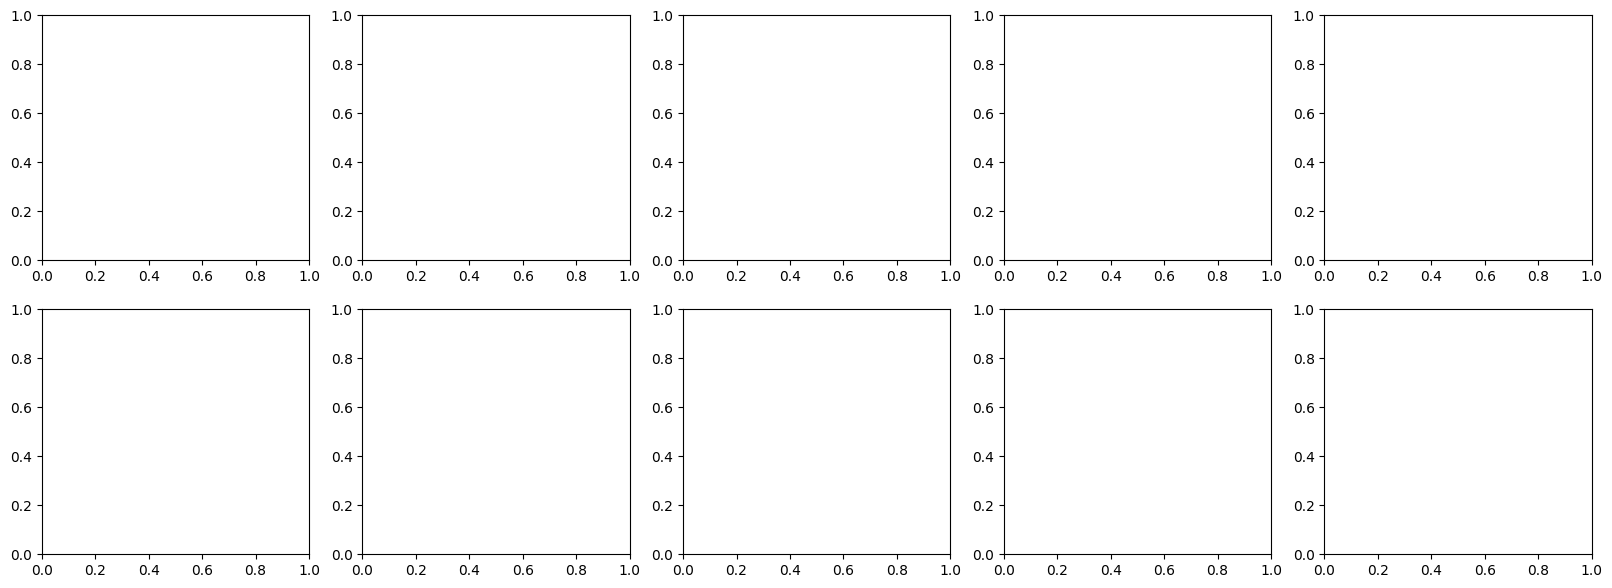

In [19]:
# Compare what two different architectures focus on
show_gradcam_grid("resnet50", n_examples=5)
show_gradcam_grid("densenet121", n_examples=5)

## 14. Summary — basic vs advanced

| Aspect | Basic notebook | Advanced notebook |
|---|---|---|
| GPUs used | 1 (one T4 idle) | **2** — two models train in parallel per wave |
| Models | 2 similar ResNets, sequential | **4 diverse** + ensemble |
| Imbalance | ignored | class-weighted loss + weighted sampler |
| Augmentation | h-flip only | flips, rotation, jitter, affine |
| LR schedule | constant | cosine annealing |
| Interpretability | none | **Grad-CAM** |
| Test set | balanced held-out (same images) | balanced held-out (same images) |

**What to look for:** the ensemble accuracy should be ≥ the best single model and steadier across the minority grades, and Grad-CAM should highlight the optic disc / lesion regions rather than the black background.

**Next steps:** higher input resolution, test-time augmentation, an *ordinal* loss (severity is ordered 0→4), and confidence calibration before any clinical reading.